In [1]:
from google.colab import files
uploaded = files.upload()

Saving advertising.csv to advertising.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(list(uploaded.keys())[0])

print("📊 Dataset Shape:", df.shape)
df.head()

📊 Dataset Shape: (200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


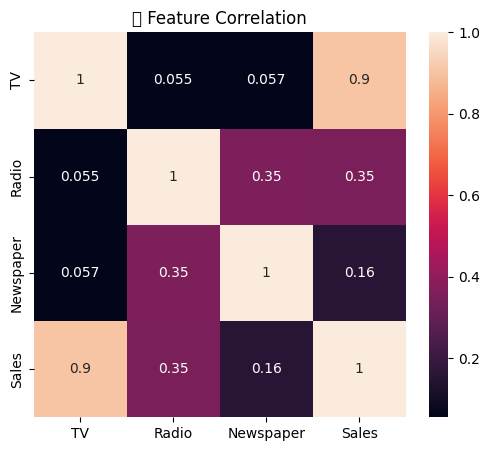

In [4]:
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True)

plt.title("📊 Feature Correlation")
plt.show()

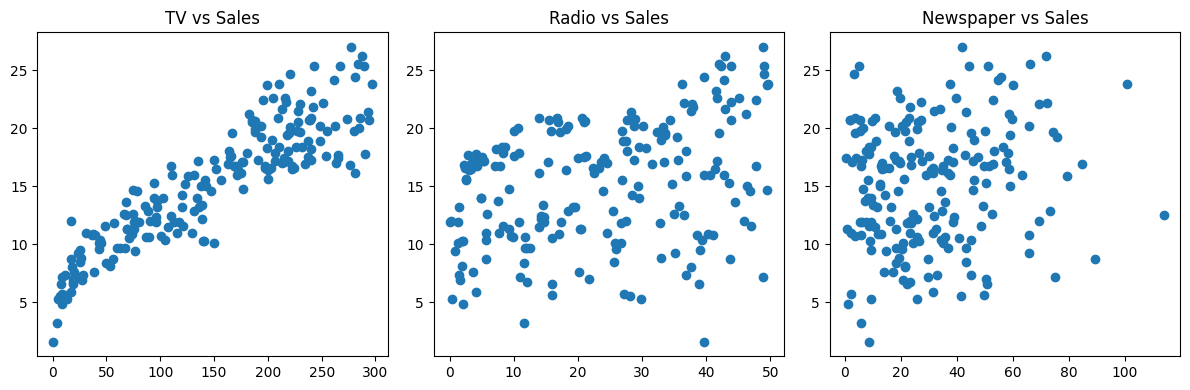

In [5]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.scatter(df['TV'], df['Sales'])
plt.title("TV vs Sales")

plt.subplot(1,3,2)
plt.scatter(df['Radio'], df['Sales'])
plt.title("Radio vs Sales")

plt.subplot(1,3,3)
plt.scatter(df['Newspaper'], df['Sales'])
plt.title("Newspaper vs Sales")

plt.tight_layout()
plt.show()

In [6]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [9]:
y_pred = model.predict(X_test)

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("📉 MAE:", mean_absolute_error(y_test, y_pred))
print("📉 MSE:", mean_squared_error(y_test, y_pred))
print("📊 R2 Score:", r2_score(y_test, y_pred))

📉 MAE: 1.2748262109549338
📉 MSE: 2.9077569102710896
📊 R2 Score: 0.9059011844150826


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


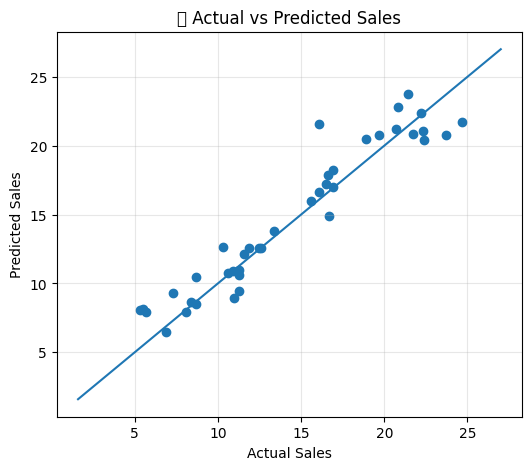

In [11]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("📈 Actual vs Predicted Sales")

plt.plot([y.min(), y.max()], [y.min(), y.max()])  # ideal line

plt.grid(alpha=0.3)
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


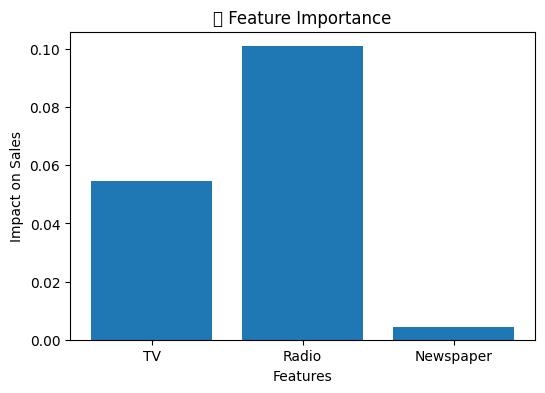

In [12]:
importance = model.coef_
features = X.columns

plt.figure(figsize=(6,4))
plt.bar(features, importance)

plt.title("📊 Feature Importance")
plt.xlabel("Features")
plt.ylabel("Impact on Sales")

plt.show()

In [13]:
new_data = [[200, 40, 50]]  # TV, Radio, Newspaper

prediction = model.predict(new_data)

print("📢 Predicted Sales:", prediction[0])

📢 Predicted Sales: 19.870627406478015


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [20]:
print("🏆 Best Model:")
print(results_df.sort_values(by="R2 Score", ascending=False).iloc[0])

🏆 Best Model:
Model       Random Forest
R2 Score         0.953235
MAE               0.89475
Name: 2, dtype: object


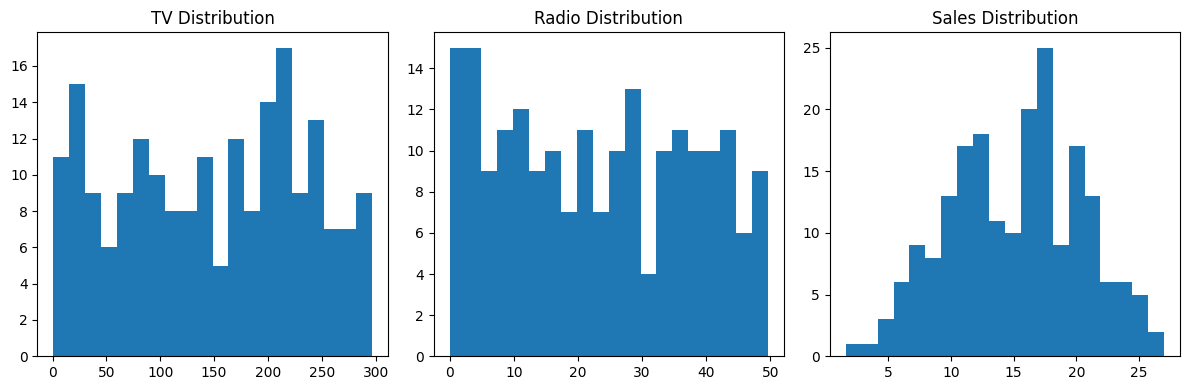

In [21]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.hist(df['TV'], bins=20)
plt.title("TV Distribution")

plt.subplot(1,3,2)
plt.hist(df['Radio'], bins=20)
plt.title("Radio Distribution")

plt.subplot(1,3,3)
plt.hist(df['Sales'], bins=20)
plt.title("Sales Distribution")

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


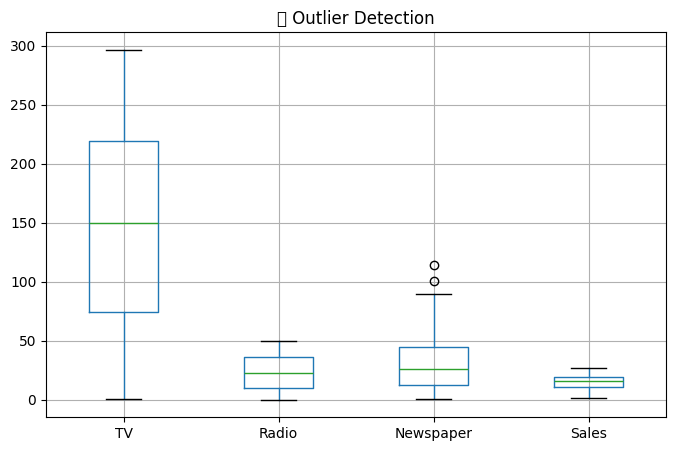

In [22]:
plt.figure(figsize=(8,5))

df.boxplot()

plt.title("📦 Outlier Detection")
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


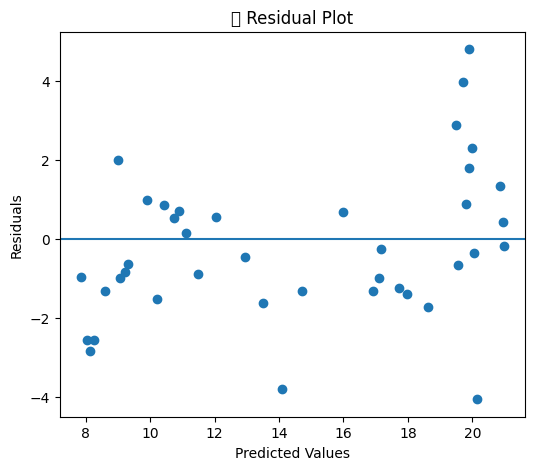

In [24]:
plt.figure(figsize=(6,5))

residuals = y_test - y_pred

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("📉 Residual Plot")

plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


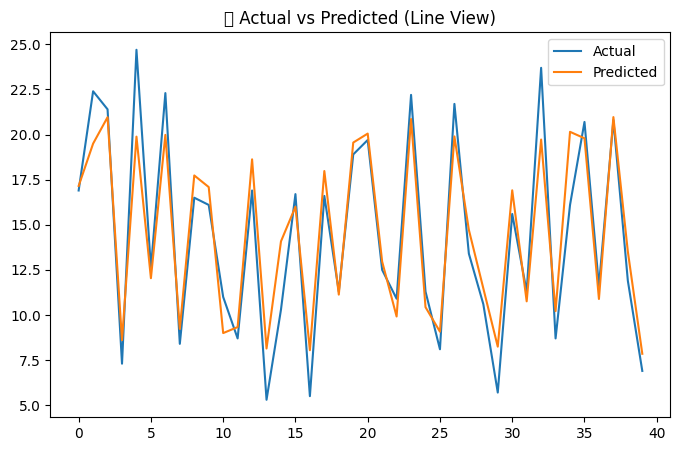

In [25]:
plt.figure(figsize=(8,5))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.legend()
plt.title("📈 Actual vs Predicted (Line View)")

plt.show()

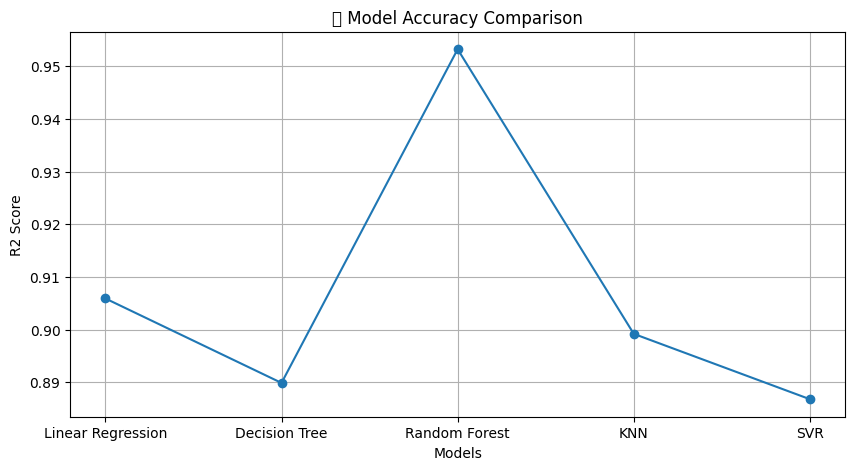

In [26]:
plt.figure(figsize=(10,5))

plt.plot(results_df["Model"], results_df["R2 Score"], marker='o')

plt.title("📈 Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("R2 Score")

plt.grid()

plt.show()